# S-SqueezeBull — out-of-sample re-validation (AUDIT, N_TRIALS = 1)

Pre-registration: [README.md](README.md) (written before any data run). Write-up: [findings.md](findings.md).

The two June-2026 rules — **OI flush long** (−2 % OI in 4 rows + price down, stop 2 % / target 3 % / TIF 48 h,
bull-gated on BTC 30d > +10 %) and **funding+CVD divergence long** (14d funding z < −2 and CVD z > +0.5 for
4 bars, 5×ATR / 6R / 72 h) — are imported from `studies/notebooks/oi_flush/` and
`studies/notebooks/funding_cvd_divergence/` unchanged. Only the window is new:
**2026-04-14 → the last full UTC day**.

Re-run order (each cell re-runs the script; all read-only against prod.db):
`run_parity.py` → `run_oos.py` → `run_combined.py` → `run_fragility.py`. The last cells
render `results/`.

`run_fragility.py` is post-hoc: it measures how thin the pre-registered verdict's margin is
(leave-k-out, the regime-gate look-ahead audit, the OI-seam split, bootstrap CIs and the
deflated Sharpe at N_TRIALS = 1). It changes no threshold and no verdict label.


## Step 2 — parity with the June numbers + data-migration caveats

In [1]:
%run run_parity.py

S-SqueezeBull re-validation — step 2: parity + data-migration caveats
frozen: FLUSH_THRESHOLD=-0.02 PRICE_DIR=-0.005 cooldown=24 rows, cost=18.0bp | fCVD WINNING={'funding_z_threshold': 2.0, 'cvd_z_threshold': 0.5, 'cvd_sustain_bars': 4, 'cooldown_bars': 96, 'z_window_days': 14}, cost=18.0bp



--- data-migration caveats
  OI seam: last OHLC row 2026-06-10 08:00:00+00:00, first snapshot row 2026-06-10 09:00:00+00:00, seam 1h change 0.0601% (median |1h| 2026 0.1739%, p99 2.1351%)
  OI snapshot rows before the seam: 33 (15 stale-CoinDesk repeats in 2022/2024; 18 Binance backfill rows 2026-06-02 13:00:00+00:00 -> 2026-06-03 06:00:00+00:00)
  OI hourly continuity in OOS: rows=3546 missing=0 off-grid=0 dups=0; full table missing hours=0
  px hourly continuity: OOS missing=0, since 2022 missing=0; 15m OOS missing=0
  funding: rows/day last 30d pre-cutover 23.93, first 30d post 3.0; post rows off the 8h grid 0; post hour counts {0: 149, 8: 149, 16: 149}
  funding level: mean|fr| pre30 3.271e-05 post30 4.110e-05; std pre30 4.056e-05 post30 4.216e-05



--- June table reconstruction: removed 18 backfilled OI hours (2026-06-02 13:00:00+00:00 -> 2026-06-03 06:00:00+00:00); rows through 2026-06-05 15:00: 38080 (June phase-1 n_bars 38080, today 38098) -> matches=True
  P2c July-22 backup identical to today on the June span: True ({'cd_open_interest': {'rows_today': 38102, 'rows_backup': 38102, 'only_today': 0, 'only_backup': 0, 'max_abs_value_diff_common': 0.0}, 'cd_futures_ohlcv': {'rows_today': 38102, 'rows_backup': 38102, 'only_today': 0, 'only_backup': 0, 'max_abs_value_diff_common': 0.0}})



--- P2 ablation table (rows <= 2026-06-05 19:01:47+00:00, reconstructed June rows):
  bull  got n=112 meanR=+0.285 MAR=2.05 maxDD=-3.72 annR=+7.6 OOS(2025->)=+0.562(17) cumR=+31.92 WR=0.607
  bull  ref n=112 meanR=+0.285 MAR=2.05 maxDD=-3.72 annR=+7.6 OOS=+0.562(17) cumR=+31.92 WR=0.607
  pool  got n=416 meanR=+0.009 maxDD=-19.84 OOS=-0.028(100)   ref n=416 meanR=+0.009 maxDD=-19.84 OOS=-0.028(100)
  today's table (with the 18 backfilled hours): pool n=417 meanR=+0.007 OOS=-0.038(101); bull n=112 meanR=+0.285 MAR=2.05
  migration delta (today vs June rows): pooled fires only-today=['2026-06-02 22:00:00+00:00', '2026-06-04 02:00:00+00:00'] only-June=['2026-06-03 16:00:00+00:00'] max|dR| common=0.0; bull-gated only-today=[] only-June=[] max|dR|=0.0
  P2 pass: True



--- P2b -3% anchor at the phase-2 cut (2026-06-05 17:04:40+00:00): got {'n': 221, 'bear': 49, 'flat': 106, 'bull': 66, 'mean_R': 0.005, 'maxDD': -16.49, 'IS_n': 181, 'OOS_n': 40, 'OOS_meanR': 0.069, 'bull_mean_R': 0.331, 'bull_MAR': 1.51} | ref {'n': 221, 'bear': 49, 'flat': 106, 'bull': 66, 'mean_R': 0.005, 'maxDD': -16.49, 'IS_n': 181, 'OOS_n': 40, 'OOS_meanR': 0.069, 'bull_mean_R': 0.331, 'bull_MAR': 1.51} | pass=True | today's table gives the same 221 fires: False

--- P1 phase3a window (bull fires <= 2026-02-06 17:30:00+00:00):
  got n=104 meanR=+0.280 MAR=2.18 annR=+8.10 maxDD=-3.72   | ref n=104 meanR=+0.280 MAR=2.18 annR=+8.10   | today's table n=104 meanR=+0.280 MAR=2.18
  P1 pass: True

--- P3 caller window (bull fires <= 2026-04-13 23:59:59+00:00, today's table):
  got n=104 meanR=+0.280 MAR=2.18 (ref 104±3, +0.28±0.05) within=True; fires after 2026-02-06 17:30: 0; P3 pass: True



--- P4 funding+CVD June path (2020-01-01 -> 2026-04-13, 220225 bars, 55055 funding rows):
  got n=21 meanR=+1.0898 | ref n=21 meanR=+1.0898 | matched 21/21, max|dR|=0.0 | only_in_ref=[] only_in_got=[]
  June JSON present: 21 fires; embedded copy matches JSON: True
  P4 pass: True



--- P4b (informational) handling B on the June window: n=20 meanR=+1.312; same-ts as June 17/21

PARITY: P1=True P2=True P2b=True P3=True P4=True  -> all_pass=True
wrote C:\Source\Repos\p300\studies\notebooks\squeeze_bull_revalidation\results\parity.json


## Step 3 — OOS window 2026-04-14 → last full day, informational tables

In [2]:
%run run_oos.py

S-SqueezeBull re-validation — step 3: OOS window + informational tables
cd_futures_ohlcv last row 2026-09-08 17:00:00+00:00; last full UTC day 2026-09-07; OOS = [2026-04-14 00:00:00+00:00, 2026-09-07 23:59:59+00:00]



--- Rule 1 OI flush: full-sample fires 423 (2022-01-30 06:00:00+00:00 -> 2026-09-08 17:00:00+00:00); OOS fires 20 (resolved 20, unresolved 0)
  bull-gated resolved: {'n': 10, 'mean_R': 0.2021, 'median_R': 0.273, 'sum_R': 2.021, 'WR': 0.7, 'maxDD': -1.59, 'stops': 3, 'targets': 3, 'tifs': 4, 'first': '2026-04-21 19:00:00+00:00', 'last': '2026-09-04 14:00:00+00:00'}
  pooled resolved:     {'n': 20, 'mean_R': -0.1719, 'median_R': -0.8695, 'sum_R': -3.438, 'WR': 0.45, 'maxDD': -7.369, 'stops': 10, 'targets': 5, 'tifs': 5, 'first': '2026-04-16 16:00:00+00:00', 'last': '2026-09-04 14:00:00+00:00'}
    bear_30d  n=  5 meanR=-0.59 sumR=-2.95 WR=0.2
    flat_30d  n=  5 meanR=-0.5018 sumR=-2.509 WR=0.2
    bull_30d  n= 10 meanR=0.2021 sumR=2.021 WR=0.7
  bull-gated with backward-only regime: {'n': 10, 'mean_R': 0.2462, 'median_R': 0.273, 'sum_R': 2.462, 'WR': 0.7, 'maxDD': -1.149, 'stops': 2, 'targets': 3, 'tifs': 5, 'first': '2026-04-21 19:00:00+00:00', 'last': '2026-09-04 14:00:00+00:00'}
  f


--- Rule 2 funding+CVD: 15m bars 234501 (2020-01-01 00:00:00+00:00 -> 2026-09-08 17:00:00+00:00); funding rows A=55501 B=7329
  handling A: full n=23 meanR=0.9755; pre-cutover n=21; OOS fires 2 (resolved 2, cutover-mixed 0): {'n': 2, 'mean_R': -0.2243, 'median_R': -0.2243, 'sum_R': -0.449, 'WR': 0.5, 'maxDD': -1.127, 'stops': 1, 'targets': 0, 'tifs': 1, 'first': '2026-06-05 20:30:00+00:00', 'last': '2026-06-17 13:15:00+00:00'}
    fire 2026-06-05 20:30:00+00:00  R=+0.678 tif    fz=-2.03 cz=+0.93 ret30=-0.250 resolved=True mixed=False
    fire 2026-06-17 13:15:00+00:00  R=-1.127 stop   fz=-2.35 cz=+1.02 ret30=-0.162 resolved=True mixed=False
  handling B: full n=22 meanR=1.1721; pre-cutover n=20; OOS fires 2 (resolved 2, cutover-mixed 0): {'n': 2, 'mean_R': -0.2243, 'median_R': -0.2243, 'sum_R': -0.449, 'WR': 0.5, 'maxDD': -1.127, 'stops': 1, 'targets': 0, 'tifs': 1, 'first': '2026-06-05 20:30:00+00:00', 'last': '2026-06-17 13:15:00+00:00'}
    fire 2026-06-05 20:30:00+00:00  R=+0.678 

## Step 4 — full-sample combined portfolio and the pre-registered verdict

In [3]:
%run run_combined.py

S-SqueezeBull re-validation — step 4: full-sample combined portfolio + verdict
full-sample window [2022-01-30 00:00:00+00:00, 2026-09-07 23:59:59+00:00]; parity all_pass=True

--- combined portfolio, fCVD handling A (strict span: first fire -> window end)
  OI flush bull-gated                n=114 meanR=+0.273 sumR= +31.14 WR=60% maxDD= -3.72 annR= +6.89 MAR= 1.85 span=4.52y
  funding+CVD (A)                    n= 16 meanR=+0.462 sumR=  +7.40 WR=56% maxDD= -3.61 annR= +1.65 MAR= 0.46 span=4.49y
  COMBINED                           n=130 meanR=+0.296 sumR= +38.54 WR=60% maxDD= -5.31 annR= +8.52 MAR= 1.60 span=4.52y
  June formula (window 2022-03-11 -> 2026-06-17):
    OI flush bull-gated              n=111 meanR=+0.275 sumR= +30.51 WR=60% maxDD= -3.72 annR= +7.38 MAR= 1.98 span=4.14y
    funding+CVD (A)                  n= 16 meanR=+0.462 sumR=  +7.40 WR=56% maxDD= -3.61 annR= +1.73 MAR= 0.48 span=4.27y
    COMBINED                         n=127 meanR=+0.299 sumR= +37.91 WR=60% maxDD= -


wrote C:\Source\Repos\p300\studies\notebooks\squeeze_bull_revalidation\results\fig_cum_r.png



VERDICT: BUILD — (a) n=10 mean R +0.202 >= +0.10 and (b) combined MAR 1.60 >= 1.5
  parity: {'P1': True, 'P2': True, 'P3': True, 'P4': True, 'all_pass': True}
  (a) OOS bull-gated OI flush: n=10 (need >= 10), mean R=0.2021 (BUILD >= +0.10, KILL <= 0)
  (b) full-sample combined MAR (handling A, strict span) = 1.6  [June formula 1.67; handling B 1.74; June reference 1.77]  need >= 1.5
  informational bootstrap of the OOS bull-gated mean (n=10, 10k resamples): p05=-0.306 p50=+0.202 p95=+0.702; P(mean>0)=73%; P(mean>=+0.10)=61%; without best fire +0.068, without worst +0.346
wrote C:\Source\Repos\p300\studies\notebooks\squeeze_bull_revalidation\results\summary.json


## Step 5 — fragility of the verdict (post-hoc; changes no threshold)

In [4]:
%run run_fragility.py

S-SqueezeBull re-validation — step 5: fragility of the BUILD verdict
headline: verdict BUILD; OOS bull-gated n=10 meanR=+0.2021; clause-(b) MAR 1.6; window 2026-04-14 -> 2026-09-07

--- F1 leave-k-out on the OOS bull-gated set
  drop best 1: n=9 meanR=+0.0679 sumR=+0.611 -> INCONCLUSIVE (n = 9 < 10); mean clause alone met: False
  drop best 2: n=8 meanR=-0.0999 sumR=-0.799 -> INCONCLUSIVE (n = 8 < 10); mean clause alone met: False
  jackknife (n=9 each): meanR range [+0.0679, +0.3456]; 7/10 subsets still >= +0.10
  all leave-two-out pairs (n=8): meanR range [-0.0999, +0.5251]; share >= +0.10 = 67%; share <= 0 = 7%
  concentration: 3 target exits carry +4.230 of +2.021 sum R (209%)



--- F2 regime-gate look-ahead audit
  June construction: 20/20 OOS fires read a daily close stamped at or after the fire; look-ahead [1.0, 21.0] h (mean 10.85 h)
  backward-only construction is strictly causal: True (max source-close offset -3.0 h)
  gate flips between the two constructions: 3
    2026-05-13 13:00:00+00:00  June=flat_30d (+0.0659) -> backonly=bull_30d (+0.1379)  R=-0.649
    2026-06-02 22:00:00+00:00  June=bear_30d (-0.1503) -> backonly=flat_30d (-0.0923)  R=-1.090
    2026-08-21 12:00:00+00:00  June=bull_30d (+0.1850) -> backonly=flat_30d (+0.0974)  R=-1.090
  June bull set     n=10 meanR=+0.2021 -> BUILD
  backonly bull set n=10 meanR=+0.2462 -> BUILD

--- F3 OI source seam
  seam: last CoinDesk OHLC row 2026-06-10 08:00:00+00:00, first Binance snapshot 2026-06-10 09:00:00+00:00; 1 h change across it 0.0601% (0.35x the 2026 median |1 h| move)
  bull-gated fires pre-seam  n=8 meanR=0.3499 sumR=2.799 (57.3 days of window)
  bull-gated fires post-seam n=2 meanR=-0.3893


--- F4 uncertainty on the OOS mean R
  iid bootstrap (n=10, 20000 resamples): mean R +0.2021, 90% CI [-0.3054, +0.7052], 95% CI [-0.4229, +0.8119]; P(mean>0)=73.3%; P(mean>=+0.10)=60.7%
  circular-block bootstrap (block=3): 90% CI [-0.1190, +0.5350]; P(mean>0)=83.1%; P(mean>=+0.10)=66.4%
  episode cluster bootstrap (3 episodes, sizes [8, 1, 1]): 90% CI [-0.6228, +0.3477]; P(mean>0)=74.2%; P(mean>=+0.10)=63.1%
  DSR at N_TRIALS=1: per-trade SR +0.1975 (ann +0.98, 24.85/yr), skew -0.11, kurt 1.345 -> DSR 0.7208 (z=0.585), rejects null at 0.95: False
     per-trade SR required for DSR>0.95 at n=10: 0.5483 (N=1) / 0.9458 (N=5)
  context, full-sample bull-gated (n=114): SR +0.2530 -> DSR 0.9956 (rejects at 0.95: True)
     full-sample DSR falls below 0.95 once n_trials >= 4; OOS-only already below at n_trials = 1
  clustering: 10 fires in 3 episodes (7-day linkage); 9 consecutive pairs closer than the 48 h TIF
    episode 2026-04-21 -> 2026-05-11  n=8 span=19.3d sumR=+2.799
    episode 202

## Verdict and clause map

In [5]:
import json, pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
S = json.load(open('results/summary.json', encoding='utf-8'))
P = json.load(open('results/parity.json', encoding='utf-8'))
print('VERDICT:', S['verdict'], '—', S['reason'])
print('parity:', S['parity'])
print()
print('clause map (pre-registered decision rule -> measured):')
for k, v in S['clause_map'].items():
    print(f'  {k:<32s} {v}')
print()
print('projection:', json.dumps(S['projection'], indent=2))


VERDICT: BUILD — (a) n=10 mean R +0.202 >= +0.10 and (b) combined MAR 1.60 >= 1.5
parity: {'P1': True, 'P2': True, 'P3': True, 'P4': True, 'all_pass': True}

clause map (pre-registered decision rule -> measured):
  parity_all_pass                  {'required': True, 'measured': True, 'detail': {'P1': True, 'P2': True, 'P3': True, 'P4': True}}
  a_oos_bull_gated_n               {'required': '>= 10', 'measured': 10}
  a_oos_bull_gated_mean_R          {'required': '>= +0.10 (BUILD) / <= 0 (KILL)', 'measured': 0.2021}
  b_full_sample_combined_MAR       {'required': '>= 1.5', 'measured': 1.6, 'june_formula_MAR': 1.67, 'handling_B_MAR': 1.74, 'june_reference_MAR': 1.77}
  clause_a                         True
  clause_b                         True
  clause_kill                      False

projection: {
  "fires_still_needed": 0
}


## Parity table

In [6]:
rows = []
for pid in ('P1', 'P2', 'P3', 'P4'):
    p = P[pid]
    if pid == 'P1':
        rows.append({'check': 'P1 phase3a bull (<=2026-02-06)', 'got': p['got'], 'ref': p['ref'], 'pass': p['pass']})
    elif pid == 'P2':
        rows.append({'check': 'P2 ablation fixed_020 bull', 'got': p['got_bull'], 'ref': p['ref_bull'], 'pass': p['check_bull']['pass']})
        rows.append({'check': 'P2 ablation fixed_020 pool', 'got': p['got_pool'], 'ref': p['ref_pool'], 'pass': p['check_pool']['pass']})
    elif pid == 'P3':
        rows.append({'check': 'P3 caller window bull (<=2026-04-13)', 'got': p['got'], 'ref': p['ref'],
                     'pass': p['pass'], 'gap_fires': len(p['fires_after_2026_02_06_in_window'])})
    else:
        rows.append({'check': 'P4 fCVD June ledger', 'got': {'n': p['got_n'], 'meanR': p['got_meanR'], 'matched': p['matched'],
                     'max_abs_dR': p['max_abs_dR']}, 'ref': {'n': p['ref_n'], 'meanR': p['ref_meanR']}, 'pass': p['pass']})
for r in rows:
    print(r['check'], '| pass =', r['pass'])
    print('   got:', {k: r['got'].get(k) for k in ('n', 'mean_R', 'meanR', 'MAR', 'maxDD', 'annual_R', 'OOS_n', 'OOS_meanR', 'matched', 'max_abs_dR') if k in r['got']})
    print('   ref:', r['ref'])
print()
print('data-migration caveats:')
print(json.dumps({k: P['data_quality'][k] for k in ('oi_seam', 'funding_cadence')}, indent=2)[:3000])
print('OI OOS continuity:', {k: P['data_quality']['oi_continuity_oos'][k] for k in ('rows', 'missing', 'off_grid_rows', 'duplicates')})


P1 phase3a bull (<=2026-02-06) | pass = True
   got: {'n': 104, 'meanR': 0.28, 'MAR': 2.18, 'maxDD': -3.72, 'annual_R': 8.1}
   ref: {'n': 104, 'meanR': 0.28, 'MAR': 2.18, 'annual_R': 8.1}
P2 ablation fixed_020 bull | pass = True
   got: {'n': 112, 'mean_R': 0.285, 'MAR': 2.05, 'maxDD': -3.72, 'annual_R': 7.6, 'OOS_n': 17, 'OOS_meanR': 0.562}
   ref: {'n': 112, 'mean_R': 0.285, 'MAR': 2.05, 'maxDD': -3.72, 'annual_R': 7.6, 'OOS_n': 17, 'OOS_meanR': 0.562, 'cum_R': 31.92, 'WR': 0.607, 'n_per_yr': 26.7}
P2 ablation fixed_020 pool | pass = True
   got: {'n': 416, 'mean_R': 0.009, 'MAR': 0.05, 'maxDD': -19.84, 'annual_R': 0.9, 'OOS_n': 100, 'OOS_meanR': -0.028}
   ref: {'n': 416, 'mean_R': 0.009, 'MAR': 0.05, 'maxDD': -19.84, 'OOS_n': 100, 'OOS_meanR': -0.028}
P3 caller window bull (<=2026-04-13) | pass = True
   got: {'n': 104, 'meanR': 0.28, 'MAR': 2.18, 'maxDD': -3.72, 'annual_R': 8.1}
   ref: {'n': 104, 'n_tol': 3, 'mean_R': 0.28, 'mean_R_tol': 0.05}
P4 fCVD June ledger | pass = True
 

## OOS ledgers and regime

In [7]:
O = json.load(open('results/oos.json', encoding='utf-8'))
print('OOS window:', O['oos_window'], '| last full day', O['last_full_day'])
print('OI flush bull-gated (resolved):', O['oi_flush']['bull_gated_resolved'])
print('OI flush pooled (resolved):    ', O['oi_flush']['pooled_resolved'])
print('by regime:', json.dumps(O['oi_flush']['by_regime_resolved'], indent=1))
print('regime distribution (June construction):', json.dumps(O['regime']['june_construction'], indent=1))
print('bull gate never open in OOS:', O['regime']['bull_gate_never_open'])
print()
print('OOS OI-flush ledger (pooled):')
display(pd.read_csv('results/oos_oi_flush_ledger.csv'))
print('OOS funding+CVD ledger (A = as stored, B = 8h-consistent):')
display(pd.read_csv('results/oos_funding_cvd_ledger.csv'))


OOS window: ['2026-04-14 00:00:00+00:00', '2026-09-07 23:59:59+00:00'] | last full day 2026-09-07
OI flush bull-gated (resolved): {'n': 10, 'mean_R': 0.2021, 'median_R': 0.273, 'sum_R': 2.021, 'WR': 0.7, 'maxDD': -1.59, 'stops': 3, 'targets': 3, 'tifs': 4, 'first': '2026-04-21 19:00:00+00:00', 'last': '2026-09-04 14:00:00+00:00'}
OI flush pooled (resolved):     {'n': 20, 'mean_R': -0.1719, 'median_R': -0.8695, 'sum_R': -3.438, 'WR': 0.45, 'maxDD': -7.369, 'stops': 10, 'targets': 5, 'tifs': 5, 'first': '2026-04-16 16:00:00+00:00', 'last': '2026-09-04 14:00:00+00:00'}
by regime: {
 "bear_30d": {
  "n": 5,
  "mean_R": -0.59,
  "median_R": -1.09,
  "sum_R": -2.95,
  "WR": 0.2,
  "maxDD": -3.27,
  "stops": 4,
  "targets": 1,
  "tifs": 0,
  "first": "2026-06-02 22:00:00+00:00",
  "last": "2026-07-01 07:00:00+00:00"
 },
 "flat_30d": {
  "n": 5,
  "mean_R": -0.5018,
  "median_R": -1.09,
  "sum_R": -2.509,
  "WR": 0.2,
  "maxDD": -3.919,
  "stops": 3,
  "targets": 1,
  "tifs": 1,
  "first": "20

,ts,idx,entry,oi_chg_4h,px_chg_4h,ret_30d,regime,ret_30d_backonly,regime_backonly,r_outcome,exit_kind,window_span_h,resolved
0,2026-04-16 16:00:00+00:00,36898,74140.6,-0.024667,-0.005861,0.016710,flat_30d,-0.000938,flat_30d,1.410000,target,4.0,True
1,2026-04-18 10:00:00+00:00,36940,76150.0,-0.024179,-0.012049,0.082510,flat_30d,0.081846,flat_30d,-1.090000,stop,4.0,True
2,2026-04-21 19:00:00+00:00,37021,74988.6,-0.020470,-0.010703,0.124687,bull_30d,0.100297,bull_30d,1.410000,target,4.0,True
3,2026-04-23 10:00:00+00:00,37060,77362.9,-0.042523,-0.010287,0.109082,bull_30d,0.102643,bull_30d,0.159732,tif,4.0,True
4,2026-04-27 05:00:00+00:00,37151,77730.6,-0.024056,-0.019114,0.165771,bull_30d,0.184577,bull_30d,-1.090000,stop,4.0,True
5,2026-04-29 18:00:00+00:00,37212,75470.1,-0.030508,-0.013982,0.134585,bull_30d,0.156419,bull_30d,1.410000,target,4.0,True
6,2026-05-04 10:00:00+00:00,37324,78894.8,-0.070849,-0.011649,0.186635,bull_30d,0.173300,bull_30d,1.410000,target,4.0,True
7,2026-05-06 14:00:00+00:00,37376,81471.6,-0.029099,-0.009369,0.182688,bull_30d,0.171947,bull_30d,-1.090000,stop,4.0,True
8,2026-05-07 17:00:00+00:00,37403,80053.3,-0.020693,-0.005024,0.112382,bull_30d,0.182688,bull_30d,0.355141,tif,4.0,True
9,2026-05-11 03:00:00+00:00,37485,80693.4,-0.041020,-0.018062,0.118960,bull_30d,0.126997,bull_30d,0.234500,tif,4.0,True


OOS funding+CVD ledger (A = as stored, B = 8h-consistent):


,ts,direction,entry,atr,risk,funding_z,cvd_z,r_outcome,exit_kind,resolved,cutover_mixed,handling,ret_30d,regime
0,2026-06-05 20:30:00+00:00,long,61241.8,590.726104,2953.630518,-2.030466,0.925051,0.678204,tif,True,False,A,-0.250253,bear_30d
1,2026-06-17 13:15:00+00:00,long,64884.6,184.148676,920.743379,-2.353878,1.015363,-1.126846,stop,True,False,A,-0.162289,bear_30d
2,2026-06-05 20:30:00+00:00,long,61241.8,590.726104,2953.630518,-2.030466,0.925051,0.678204,tif,True,False,B,-0.250253,bear_30d
3,2026-06-17 13:15:00+00:00,long,64884.6,184.148676,920.743379,-2.353878,1.015363,-1.126846,stop,True,False,B,-0.162289,bear_30d


## Per-year, ETF split, combined portfolio, cumulative R

per-year (full sample):


,year,oi_pool_n,oi_pool_meanR,oi_pool_sumR,oi_bull_n,oi_bull_meanR,oi_bull_sumR,oi_bull_WR,fcdA_n,fcdA_meanR,fcdA_sumR,fcdB_n,fcdB_meanR,fcdB_sumR
0,2020,0,NaN,NaN,0,NaN,NaN,NaN,3,2.814,8.44,3,2.814,8.44
1,2021,0,NaN,NaN,0,NaN,NaN,NaN,4,1.649,6.60,4,1.649,6.60
2,2022,116,-0.034,-3.93,14,-0.056,-0.78,0.43,6,-0.380,-2.28,5,-0.246,-1.23
3,2023,102,0.089,9.05,44,0.292,12.86,0.57,3,3.293,9.88,3,3.293,9.88
4,2024,98,0.016,1.54,37,0.278,10.28,0.65,1,1.832,1.83,1,1.832,1.83
5,2025,66,0.027,1.78,9,0.751,6.76,0.78,2,0.245,0.49,2,0.157,0.31
6,2026,41,-0.202,-8.27,10,0.202,2.02,0.70,4,-0.631,-2.52,4,-0.012,-0.05


pre-ETF vs post-ETF (2024-01-11):


,period,sleeve,n,mean_R,sum_R,WR,maxDD
0,pre_ETF (<2024-01-11),OI_pooled,223,0.0173,3.851,0.471,-19.843
1,pre_ETF (<2024-01-11),OI_bull_gated,59,0.2287,13.491,0.542,-3.720
2,pre_ETF (<2024-01-11),fCVD_A,9,0.8446,7.601,0.667,-1.752
3,pre_ETF (<2024-01-11),fCVD_B,8,1.0812,8.650,0.750,-1.052
4,post_ETF (>=2024-01-11),OI_pooled,200,-0.0183,-3.669,0.470,-15.633
5,post_ETF (>=2024-01-11),OI_bull_gated,55,0.3209,17.650,0.673,-3.270
6,post_ETF (>=2024-01-11),fCVD_A,7,-0.0288,-0.201,0.429,-3.605
7,post_ETF (>=2024-01-11),fCVD_B,7,0.2999,2.099,0.571,-1.494


combined portfolio, fCVD handling A:


,label,n,meanR,sumR,WR,maxDD,annual_R,MAR,span_y,first_fire,window_end
0,OI_bull,114,0.273,31.14,0.605,-3.72,6.89,1.85,4.521,2022-03-01 16:00:00+00:00,2026-09-07 23:59:59+00:00
1,fCVD_A,16,0.462,7.40,0.562,-3.61,1.65,0.46,4.494,2022-03-11 12:00:00+00:00,2026-09-07 23:59:59+00:00
2,combined,130,0.296,38.54,0.600,-5.31,8.52,1.60,4.521,2022-03-01 16:00:00+00:00,2026-09-07 23:59:59+00:00


   June formula: {'label': 'combined', 'n': 127, 'meanR': 0.299, 'sumR': 37.91, 'WR': 0.598, 'maxDD': -5.31, 'annual_R': 8.88, 'MAR': 1.67, 'span_y': 4.268} | monthly Pearson r = 0.016948143249209235 over 36 months
combined portfolio, fCVD handling B:


,label,n,meanR,sumR,WR,maxDD,annual_R,MAR,span_y,first_fire,window_end
0,OI_bull,114,0.273,31.14,0.605,-3.72,6.89,1.85,4.521,2022-03-01 16:00:00+00:00,2026-09-07 23:59:59+00:00
1,fCVD_B,15,0.717,10.75,0.667,-1.49,2.44,1.63,4.406,2022-04-12 15:15:00+00:00,2026-09-07 23:59:59+00:00
2,combined,129,0.325,41.89,0.612,-5.31,9.27,1.74,4.521,2022-03-01 16:00:00+00:00,2026-09-07 23:59:59+00:00


   June formula: {'label': 'combined', 'n': 123, 'meanR': 0.326, 'sumR': 40.05, 'WR': 0.61, 'maxDD': -4.45, 'annual_R': 9.58, 'MAR': 2.15, 'span_y': 4.18} | monthly Pearson r = 0.01943919898029189 over 36 months


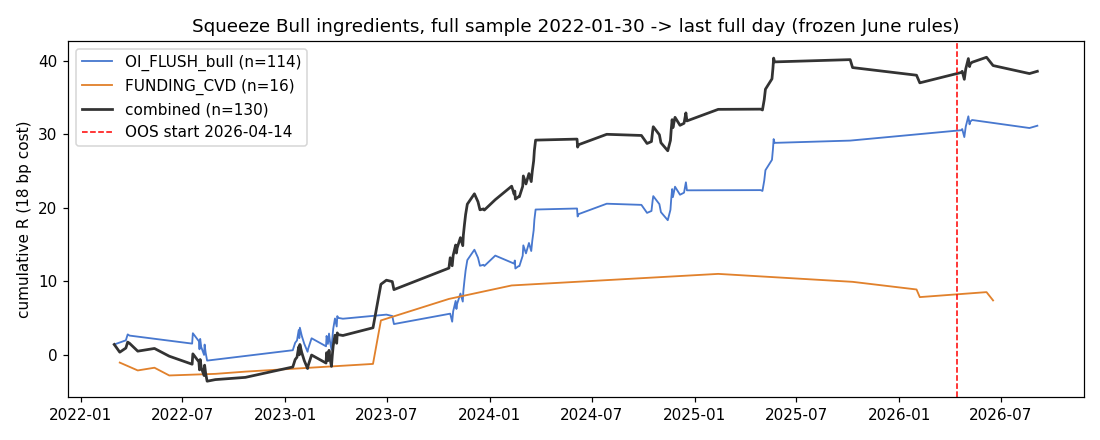

In [8]:
print('per-year (full sample):'); display(pd.read_csv('results/per_year.csv'))
print('pre-ETF vs post-ETF (2024-01-11):'); display(pd.read_csv('results/etf_split.csv'))
C = S['combined']
for h in ('A', 'B'):
    print(f'combined portfolio, fCVD handling {h}:')
    display(pd.DataFrame([C[h]['strict']['OI_bull'], C[h]['strict']['fCVD'], C[h]['strict']['combined']]))
    print(f"   June formula: {C[h]['june_formula']['combined']} | monthly Pearson r = {C[h]['monthly_pearson']} over {C[h]['active_months']} months")
display(Image('results/fig_cum_r.png'))


## Fragility of the BUILD

Post-hoc measurement of an already-frozen verdict — leave-k-out, the regime-gate
look-ahead audit, the OI-seam split, bootstrap CIs and the deflated Sharpe at
N_TRIALS = 1. Nothing here changes a threshold or the verdict label; the discussion
is in [findings.md](findings.md).

In [9]:
F = json.load(open('results/fragility.json', encoding='utf-8'))
print('verdict under the frozen rule (unchanged by anything below):', F['headline_verdict_unchanged'])
print('margins over the pre-registered thresholds:', F['margins'])
print()
print('F1 leave-k-out on the OOS bull-gated set')
for k in ('drop_best_1', 'drop_best_2'):
    d = F['F1_leave_k_out'][k]
    print(f"  {k}: n={d['n']} meanR={d['mean_R']:+.4f} sumR={d['sum_R']:+.3f} -> {d['verdict']} ({d['why']})")
print('  jackknife:', F['F1_leave_k_out']['jackknife_leave_one_out'])
print('  all leave-two-out pairs:', F['F1_leave_k_out']['leave_two_out_all_pairs'])
print('  concentration:', F['F1_leave_k_out']['concentration'])
print()
R = F['F2_regime_gate_lookahead']
print('F2 regime-gate look-ahead: '
      f"{R['fires_whose_gate_source_close_is_at_or_after_the_fire']}/{R['oos_fires']} OOS fires read a daily "
      f"close stamped at or after the fire; range [{R['min_lookahead_hours']}, {R['max_lookahead_hours']}] h")
print('  backward-only construction is strictly causal:', R['backonly_is_implementable'])
print('  gate flips:', json.dumps(R['gate_flips'], indent=1))
print(f"  June bull set     n={R['june_bull_set']['n']} meanR={R['june_bull_set']['mean_R']:+.4f} (DECISION-BEARING)")
print(f"  backonly bull set n={R['backonly_bull_set']['n']} meanR={R['backonly_bull_set']['mean_R']:+.4f} (sensitivity)")
display(pd.read_csv('results/fragility_regime_audit.csv'))
print()
S3 = F['F3_oi_seam']
print('F3 OI source seam:', S3['seam'])
print(f"  bull-gated pre-seam  n={S3['bull_gated_pre_seam']['n']} meanR={S3['bull_gated_pre_seam']['mean_R']}")
print(f"  bull-gated post-seam n={S3['bull_gated_post_seam']['n']} meanR={S3['bull_gated_post_seam']['mean_R']}")
print('  post-seam subset alone ->', S3['post_seam_verdict_if_it_were_the_whole_sample'])
print()
U = F['F4_uncertainty']
print('F4 uncertainty on the OOS mean R')
for k in ('iid_bootstrap_mean_R', 'block_bootstrap_mean_R_block3', 'episode_cluster_bootstrap_mean_R',
          'dsr_oos_bull_gated', 'dsr_full_sample_bull_gated_context',
          'n_trials_breakeven_full_sample', 'clustering'):
    print(f'  {k}:', json.dumps(U[k], indent=1))
print('  N_TRIALS justification:', U['n_trials_justification'])
print()
print('F5 clause (b) decomposition:')
display(pd.DataFrame([{'set': k, **F['F5_clause_b'][k]} for k in
                      ('combined_full_sample', 'oi_bull_only_full_sample', 'fcd_only_full_sample',
                       'combined_pre_OOS_only', 'oi_bull_pre_OOS_only', 'fcd_pre_OOS_only')]))
print('  fCVD share of combined sum R:', F['F5_clause_b']['fcd_share_of_combined_sum_R'],
      '| OOS contribution to combined sum R:', F['F5_clause_b']['oos_contribution_to_combined_sum_R'])


verdict under the frozen rule (unchanged by anything below): BUILD
margins over the pre-registered thresholds: {'n_margin': 0, 'mean_R_margin': 0.1021, 'MAR_margin': 0.1}

F1 leave-k-out on the OOS bull-gated set
  drop_best_1: n=9 meanR=+0.0679 sumR=+0.611 -> INCONCLUSIVE (n = 9 < 10)
  drop_best_2: n=8 meanR=-0.0999 sumR=-0.799 -> INCONCLUSIVE (n = 8 < 10)
  jackknife: {'n_each': 9, 'min_mean_R': 0.0679, 'max_mean_R': 0.3456, 'median_mean_R': 0.1942, 'n_subsets_mean_ge_0.10': 7, 'n_subsets': 10}
  all leave-two-out pairs: {'n_each': 8, 'n_pairs': 45, 'min_mean_R': -0.0999, 'max_mean_R': 0.5251, 'median_mean_R': 0.2126, 'share_pairs_mean_ge_0.10': 0.667, 'share_pairs_mean_le_0': 0.067}
  concentration: {'sum_R': 2.021, 'sum_R_from_target_exits': 4.23, 'share_of_sum_R_from_targets': 2.093, 'n_targets': 3, 'note': 'every target exit pays exactly +1.410 R (3 % move / 2 % stop, minus 18 bp)'}

F2 regime-gate look-ahead: 20/20 OOS fires read a daily close stamped at or after the fire; rang

,ts,regime_june,ret_30d_june,regime_backonly,ret_30d_backonly,r_outcome,june_gate_source_close_ts,june_lookahead_hours,backonly_gate_source_close_ts,backonly_lookahead_hours,gate_flips
0,2026-04-16 16:00:00+00:00,flat_30d,0.016710,flat_30d,-0.000938,1.410000,2026-04-16 23:00:00+00:00,7.0,2026-04-15 23:00:00+00:00,-17.0,False
1,2026-04-18 10:00:00+00:00,flat_30d,0.082510,flat_30d,0.081846,-1.090000,2026-04-18 23:00:00+00:00,13.0,2026-04-17 23:00:00+00:00,-11.0,False
2,2026-04-21 19:00:00+00:00,bull_30d,0.124687,bull_30d,0.100297,1.410000,2026-04-21 23:00:00+00:00,4.0,2026-04-20 23:00:00+00:00,-20.0,False
3,2026-04-23 10:00:00+00:00,bull_30d,0.109082,bull_30d,0.102643,0.159732,2026-04-23 23:00:00+00:00,13.0,2026-04-22 23:00:00+00:00,-11.0,False
4,2026-04-27 05:00:00+00:00,bull_30d,0.165771,bull_30d,0.184577,-1.090000,2026-04-27 23:00:00+00:00,18.0,2026-04-26 23:00:00+00:00,-6.0,False
5,2026-04-29 18:00:00+00:00,bull_30d,0.134585,bull_30d,0.156419,1.410000,2026-04-29 23:00:00+00:00,5.0,2026-04-28 23:00:00+00:00,-19.0,False
6,2026-05-04 10:00:00+00:00,bull_30d,0.186635,bull_30d,0.173300,1.410000,2026-05-04 23:00:00+00:00,13.0,2026-05-03 23:00:00+00:00,-11.0,False
7,2026-05-06 14:00:00+00:00,bull_30d,0.182688,bull_30d,0.171947,-1.090000,2026-05-06 23:00:00+00:00,9.0,2026-05-05 23:00:00+00:00,-15.0,False
8,2026-05-07 17:00:00+00:00,bull_30d,0.112382,bull_30d,0.182688,0.355141,2026-05-07 23:00:00+00:00,6.0,2026-05-06 23:00:00+00:00,-18.0,False
9,2026-05-11 03:00:00+00:00,bull_30d,0.118960,bull_30d,0.126997,0.234500,2026-05-11 23:00:00+00:00,20.0,2026-05-10 23:00:00+00:00,-4.0,False



F3 OI source seam: {'last_coindesk_ohlc_row': '2026-06-10 08:00:00+00:00', 'first_binance_snapshot_row': '2026-06-10 09:00:00+00:00', 'seam_1h_oi_change_pct': 0.0601, 'median_abs_1h_change_pct_2026': 0.1739, 'p99_abs_1h_change_pct_2026': 2.1351, 'seam_move_vs_median': 0.35}
  bull-gated pre-seam  n=8 meanR=0.3499
  bull-gated post-seam n=2 meanR=-0.3893
  post-seam subset alone -> ['INCONCLUSIVE', 'n = 2 < 10']

F4 uncertainty on the OOS mean R
  iid_bootstrap_mean_R: {
 "n": 10,
 "point_mean_R": 0.2021,
 "n_iter": 20000,
 "p02.5": -0.4229,
 "p05": -0.3054,
 "p50": 0.2021,
 "p95": 0.7052,
 "p97.5": 0.8119,
 "P_mean_gt_0": 0.7327,
 "P_mean_ge_0.10": 0.6065
}
  block_bootstrap_mean_R_block3: {
 "block": 3,
 "n_iter": 20000,
 "p05": -0.119,
 "p50": 0.2021,
 "p95": 0.535,
 "P_mean_gt_0": 0.8306,
 "P_mean_ge_0.10": 0.6639
}
  episode_cluster_bootstrap_mean_R: {
 "n_episodes": 3,
 "n_iter": 20000,
 "episode_sizes": [
  8,
  1,
  1
 ],
 "p05": -0.6228,
 "p50": 0.2021,
 "p95": 0.3477,
 "P_mea

,set,n,meanR,sumR,maxDD,annual_R,MAR,span_y
0,combined_full_sample,130,0.296,38.54,-5.31,8.52,1.60,4.521
1,oi_bull_only_full_sample,114,0.273,31.14,-3.72,6.89,1.85,4.521
2,fcd_only_full_sample,16,0.462,7.40,-3.61,1.65,0.46,4.494
3,combined_pre_OOS_only,118,0.313,36.97,-5.31,8.98,1.69,4.119
4,oi_bull_pre_OOS_only,104,0.280,29.12,-3.72,7.07,1.90,4.119
5,fcd_pre_OOS_only,14,0.561,7.85,-3.16,1.92,0.61,4.092


  fCVD share of combined sum R: 0.192 | OOS contribution to combined sum R: 1.572
